In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.preprocessing import MinMaxScaler

In [4]:
df = pd.read_excel("Assignments/DataScience(Week3_Assignment) (1).xlsx")


In [5]:
df.head()

,converted_speedColor,converted_speedMono,deviceProductFamily,deviceType,guid,listPrice,make,model,printTechnology,productNumber,...,region,country,width,depth,height,weight,standardInputCapacity,printDPI,scan,hasWifi
0,0.0,600.0,ad acl 7350/7450,dot matrix,AD0001,1861.24,amt datasouth,Accel 7350,dot matrix,AMT7350,...,North America,United States,25.0,18.3,11.6,51.81,0,360 x 360,False,False
1,0.0,600.0,ad acl 7350/7450,dot matrix,AD0002,2304.99,amt datasouth,ACCEL-7450,dot matrix,AMT7450,...,North America,United States,25.0,18.3,11.6,52.00,0,360 x 360,False,False
2,0.0,600.0,ad acl 6310/6350,dot matrix,AD0003,1748.49,amt datasouth,ACCEL 6350,dot matrix,A6350,...,North America,United States,24.0,16.8,8.2,44.97,0,360 x 240,False,False
3,4.0,7.0,ao p 2600p/2600u,printcolor,AO0007,457.27,apollo,P-2600P,inkjet,P2600P,...,North America,United States,18.6,15.4,8.7,11.90,100,600 x 600,False,False
4,1.5,3.5,ao p 1250i,printcolor,AO0008,586.12,apollo,P-1250i,inkjet,P1250I,...,North America,United States,13.7,6.4,6.9,6.61,50,600 x 300,False,False


In [8]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 11878 entries, 0 to 11877
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   converted_speedColor   11878 non-null  float64
 1   converted_speedMono    11878 non-null  float64
 2   deviceProductFamily    11878 non-null  str    
 3   deviceType             11878 non-null  str    
 4   guid                   11878 non-null  str    
 5   listPrice              11878 non-null  float64
 6   make                   11878 non-null  str    
 7   model                  11878 non-null  str    
 8   printTechnology        11878 non-null  str    
 9   productNumber          11878 non-null  str    
 10  assetClass             11878 non-null  str    
 11  region                 11878 non-null  str    
 12  country                11878 non-null  str    
 13  width                  11878 non-null  float64
 14  depth                  11878 non-null  float64
 15  height       

converted_speedColor     0
converted_speedMono      0
deviceProductFamily      0
deviceType               0
guid                     0
listPrice                0
make                     0
model                    0
printTechnology          0
productNumber            0
assetClass               0
region                   0
country                  0
width                    0
depth                    0
height                   0
weight                   0
standardInputCapacity    0
printDPI                 0
scan                     0
hasWifi                  0
dtype: int64

In [ ]:
# Drop columns 'country', 'region'. Rename Column 'converted_speedColor' to 'SpeedColor' and 'converted_speedMono' to 'SpeedMono'

In [9]:
df = df.drop(columns=['country','region'])

In [10]:
df = df.rename(columns={
    'converted_speedColor':'SpeedColor',
    'converted_speedMono':'SpeedMono'
})

In [11]:
df.head()

,SpeedColor,SpeedMono,deviceProductFamily,deviceType,guid,listPrice,make,model,printTechnology,productNumber,assetClass,width,depth,height,weight,standardInputCapacity,printDPI,scan,hasWifi
0,0.0,600.0,ad acl 7350/7450,dot matrix,AD0001,1861.24,amt datasouth,Accel 7350,dot matrix,AMT7350,Home/Small Office/Workgroup,25.0,18.3,11.6,51.81,0,360 x 360,False,False
1,0.0,600.0,ad acl 7350/7450,dot matrix,AD0002,2304.99,amt datasouth,ACCEL-7450,dot matrix,AMT7450,Home/Small Office/Workgroup,25.0,18.3,11.6,52.00,0,360 x 360,False,False
2,0.0,600.0,ad acl 6310/6350,dot matrix,AD0003,1748.49,amt datasouth,ACCEL 6350,dot matrix,A6350,Workgroup,24.0,16.8,8.2,44.97,0,360 x 240,False,False
3,4.0,7.0,ao p 2600p/2600u,printcolor,AO0007,457.27,apollo,P-2600P,inkjet,P2600P,Home/Small Office/Workgroup,18.6,15.4,8.7,11.90,100,600 x 600,False,False
4,1.5,3.5,ao p 1250i,printcolor,AO0008,586.12,apollo,P-1250i,inkjet,P1250I,Home/Small Office/Workgroup,13.7,6.4,6.9,6.61,50,600 x 300,False,False


In [ ]:
#Transform printDPI - 'A x B' to 'A multiplied by B' and do min max scaling after grouping on 'printTechnology' and 'assetClass' separately. Compare the result.  


In [28]:
dpi = df['printDPI'].str.lower().str.replace(' ', '').str.split('x', expand=True)

df['printDPI_numeric'] = pd.to_numeric(dpi[0], errors='coerce') * pd.to_numeric(dpi[1], errors='coerce')

In [29]:
df[['printDPI','printDPI_numeric']].head()

,printDPI,printDPI_numeric
0,360 x 360,129600.0
1,360 x 360,129600.0
2,360 x 240,86400.0
3,600 x 600,360000.0
4,600 x 300,180000.0


In [22]:
df['dpi_scaled_printTech'] = df.groupby('printTechnology')['printDPI_numeric']\
.transform(lambda x: (x - x.min()) / (x.max() - x.min()))

In [23]:
df['dpi_scaled_assetClass'] = df.groupby('assetClass')['printDPI_numeric']\
.transform(lambda x: (x - x.min()) / (x.max() - x.min()))

In [24]:

df[['printTechnology','assetClass',
    'printDPI_numeric',
    'dpi_scaled_printTech',
    'dpi_scaled_assetClass']].head()

,printTechnology,assetClass,printDPI_numeric,dpi_scaled_printTech,dpi_scaled_assetClass
0,dot matrix,Home/Small Office/Workgroup,129600.0,0.009450,0.001250
1,dot matrix,Home/Small Office/Workgroup,129600.0,0.009450,0.001250
2,dot matrix,Workgroup,86400.0,0.006115,0.001289
3,inkjet,Home/Small Office/Workgroup,360000.0,0.013913,0.003751
4,inkjet,Home/Small Office/Workgroup,180000.0,0.006087,0.001797


In [66]:
#For converted_speedColor (or SpeedColor), converted_speedMono (or SpeedMono), listPrice, width, depth, height, weight, and standardInputCapacity;
#a. Find Mean, Median, Mode, standard deviation. Any observation? 

In [30]:
cols = ['SpeedColor','SpeedMono','listPrice',
        'width','depth','height','weight','standardInputCapacity']

In [34]:
df[cols].mean()



SpeedColor                 19.352323
SpeedMono                  51.799728
listPrice                7819.216068
width                      23.649937
depth                      22.033379
height                     21.772077
weight                    181.707994
standardInputCapacity     761.502273
dtype: float64

In [35]:
df[cols].median()



SpeedColor                  2.700
SpeedMono                  28.000
listPrice                1299.000
width                      18.900
depth                      19.500
height                     16.540
weight                     50.795
standardInputCapacity     350.000
dtype: float64

In [36]:


df[cols].mode().iloc[0]


SpeedColor                 0.00
SpeedMono                 35.00
listPrice                199.99
width                     16.50
depth                     26.00
height                     0.00
weight                     0.00
standardInputCapacity      0.00
Name: 0, dtype: float64

In [37]:


df[cols].std()

SpeedColor                 303.340260
SpeedMono                  422.140735
listPrice                32516.045650
width                       22.450032
depth                       43.693563
height                      20.799448
weight                     881.016573
standardInputCapacity     1234.715944
dtype: float64

In [67]:
#b. Find Percentiles, Quartiles, Quintiles, Deciles
df[cols].quantile([0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99])

In [39]:
df[cols].quantile([0.25,0.50,0.75])

,SpeedColor,SpeedMono,listPrice,width,depth,height,weight,standardInputCapacity
0.25,0.0,17.0,399.0,16.53,15.3,9.60,19.185,120.0
0.50,2.7,28.0,1299.0,18.90,19.5,16.54,50.795,350.0
0.75,22.0,45.0,5995.0,24.40,26.0,30.00,163.140,1050.0


In [40]:
df[cols].quantile([0.2,0.4,0.6,0.8])

,SpeedColor,SpeedMono,listPrice,width,depth,height,weight,standardInputCapacity
0.2,0.0,15.0,331.336,16.0,14.5,8.460,15.87,100.0
0.4,0.0,24.0,749.000,17.6,17.7,13.564,36.00,250.0
0.6,8.0,33.0,2393.656,21.4,21.9,19.900,75.00,600.0
0.8,26.0,50.0,8200.000,26.0,26.9,34.000,191.48,1100.0


In [41]:
df[cols].quantile([0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])

,SpeedColor,SpeedMono,listPrice,width,depth,height,weight,standardInputCapacity
0.1,0.0,8.2,199.950,14.400,11.4,6.500,10.000,0.0
0.2,0.0,15.0,331.336,16.000,14.5,8.460,15.870,100.0
0.3,0.0,20.0,496.350,16.890,16.0,10.600,23.800,150.0
0.4,0.0,24.0,749.000,17.600,17.7,13.564,36.000,250.0
0.5,2.7,28.0,1299.000,18.900,19.5,16.540,50.795,350.0
0.6,8.0,33.0,2393.656,21.400,21.9,19.900,75.000,600.0
0.7,18.0,40.0,4250.000,23.300,25.0,26.889,126.000,650.0
0.8,26.0,50.0,8200.000,26.000,26.9,34.000,191.480,1100.0
0.9,40.0,70.0,17542.969,34.886,30.3,45.300,326.280,1750.0


In [42]:
 #Find IQR and Plot Boxplots.
Q1 = df[cols].quantile(0.25)
Q3 = df[cols].quantile(0.75)

IQR = Q3 - Q1

IQR

SpeedColor                 22.000
SpeedMono                  28.000
listPrice                5596.000
width                       7.870
depth                      10.700
height                     20.400
weight                    143.955
standardInputCapacity     930.000
dtype: float64

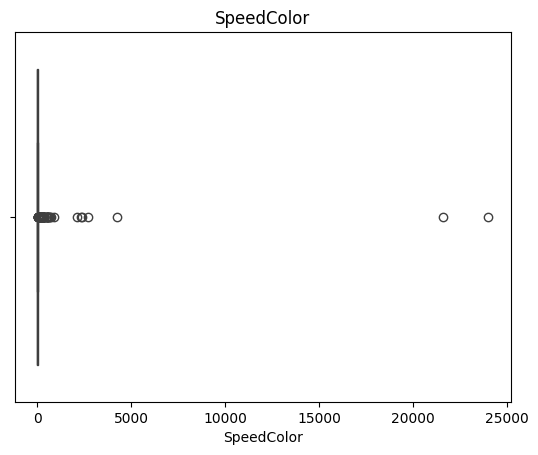

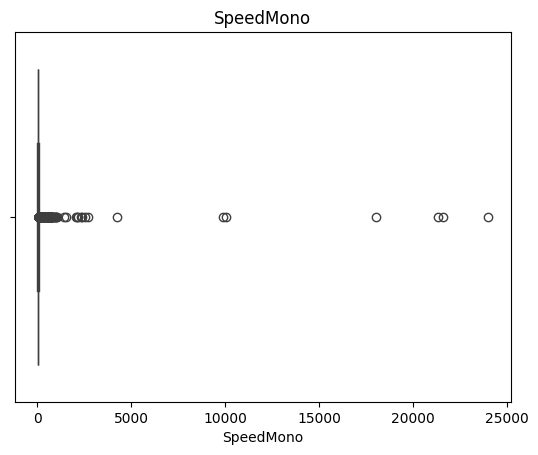

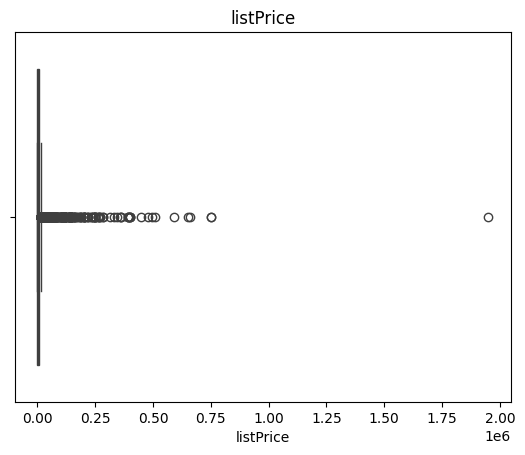

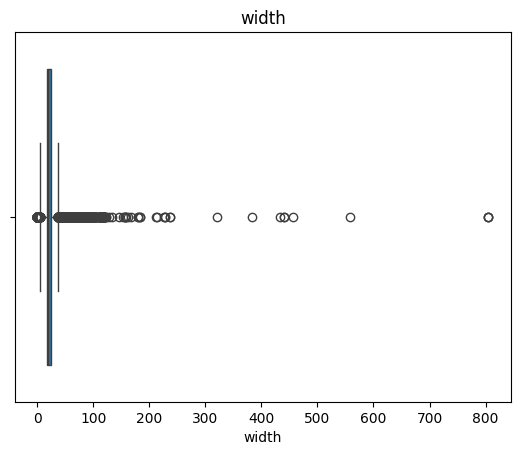

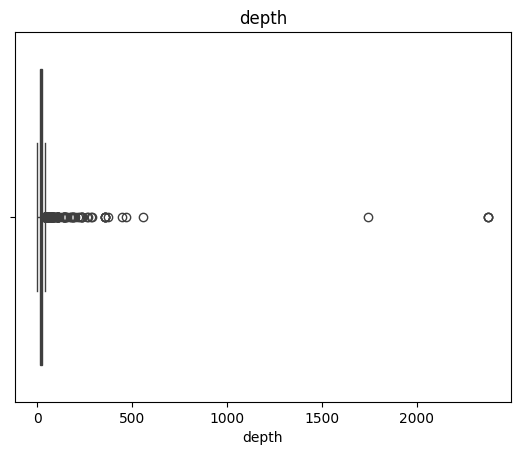

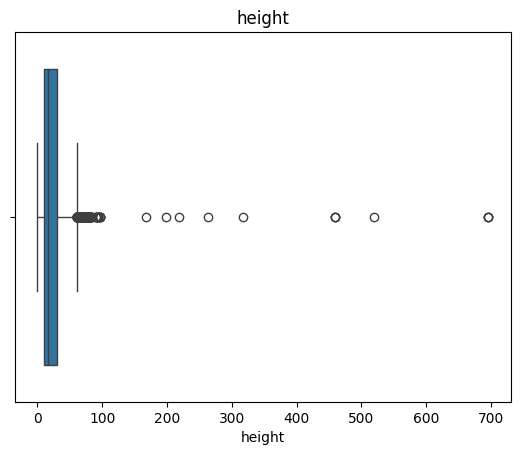

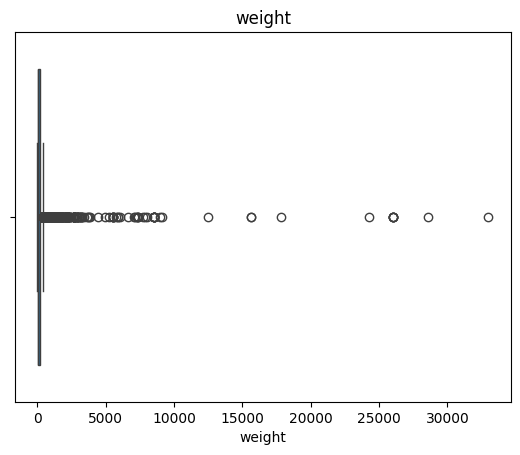

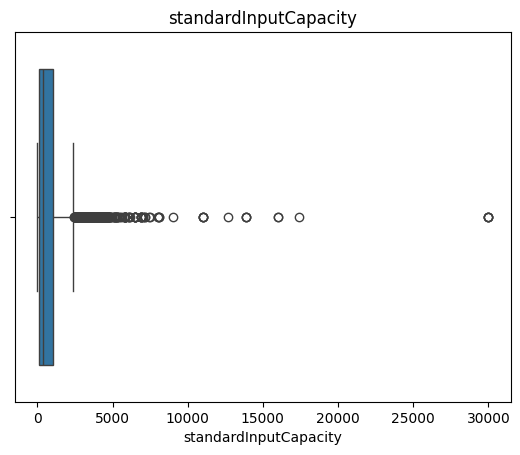

In [43]:

    sns.boxplot(x=df[feature])
    plt.title(feature)
    plt.show()

In [68]:
# Group by printTechnology and Find IQR and Plot Boxplotsfor feature in cols:
group_IQR = df.groupby('printTechnology')[cols].quantile(0.75) - \
            df.groupby('printTechnology')[cols].quantile(0.25)

group_IQR

,SpeedColor,SpeedMono,listPrice,width,depth,height,weight,standardInputCapacity
printTechnology,,,,,,,,
direct thermal/thermal transfer,0.00,192.988333,1164.6750,5.1800,9.4950,6.9650,31.0500,0.0
dot matrix,0.00,297.500000,343.0500,8.2000,3.6000,3.1750,13.1025,0.0
dye sublimation/thermal resin,0.00,0.000000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0
dye-sublimation / retransfer,0.00,0.000000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0
fused deposition,0.00,0.000000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0
inkjet,15.00,17.000000,423.0150,3.1550,7.7375,5.9075,17.0500,70.0
laser,25.00,23.000000,8218.0400,9.0000,9.4000,19.3000,164.0000,850.0
line thermal,0.00,974.000000,5975.0100,15.1000,23.2000,29.1000,279.5500,0.0
multi jet fusion,27.75,154.500000,150750.0000,25.4000,10.1500,3.5000,291.7500,0.0


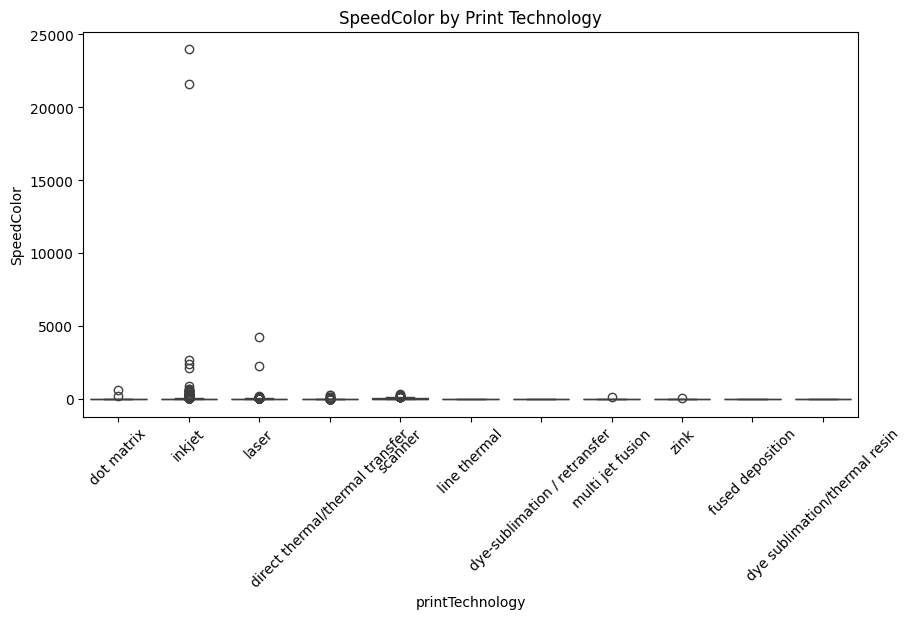

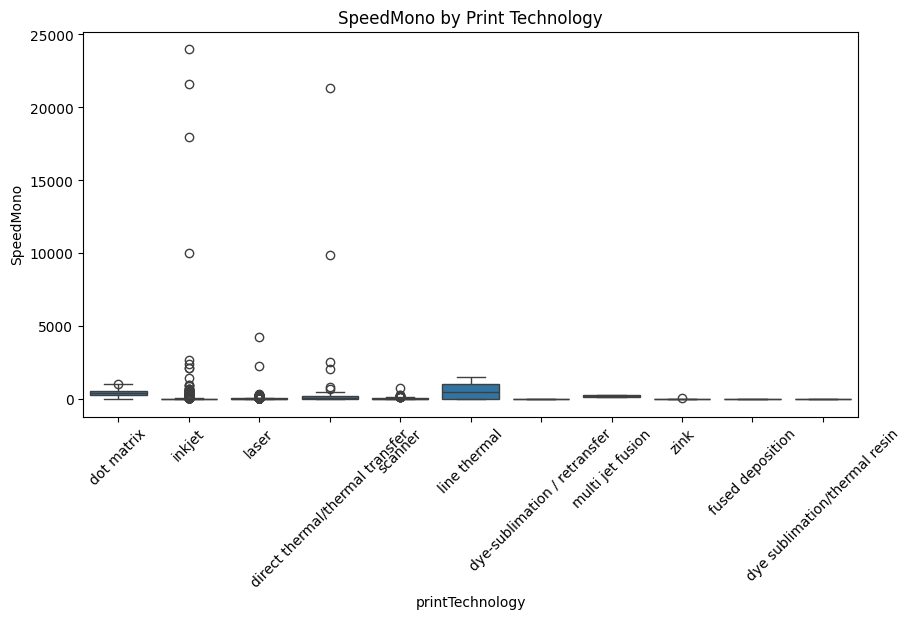

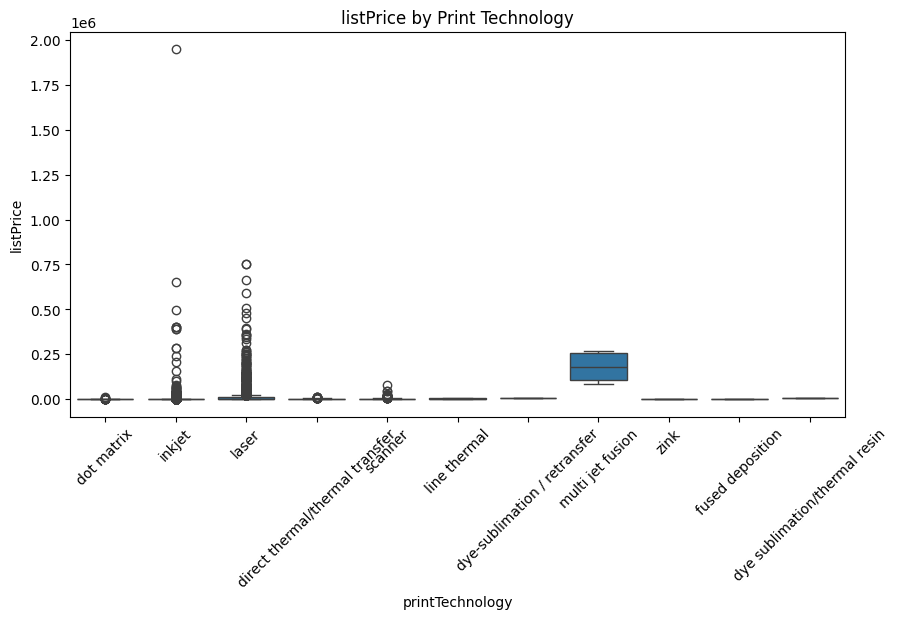

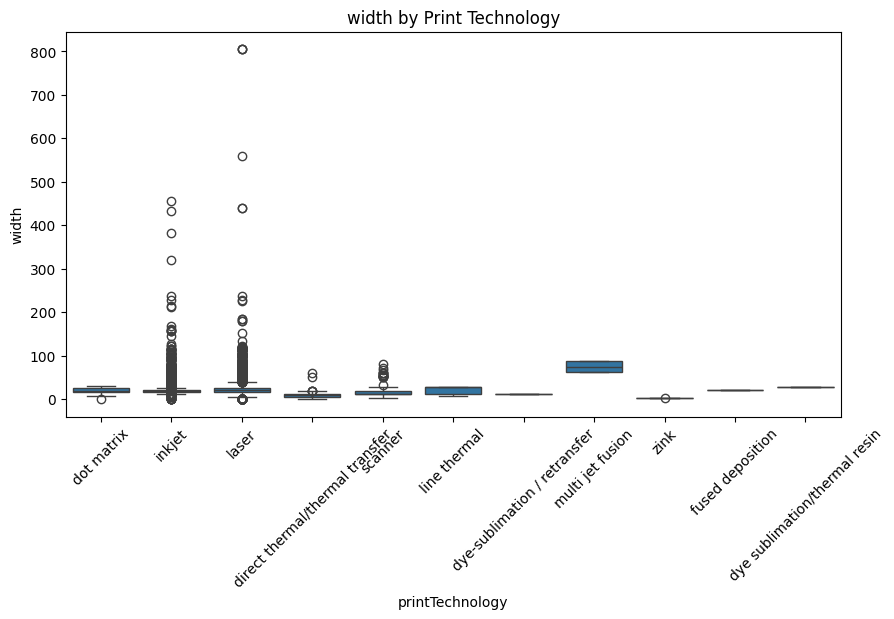

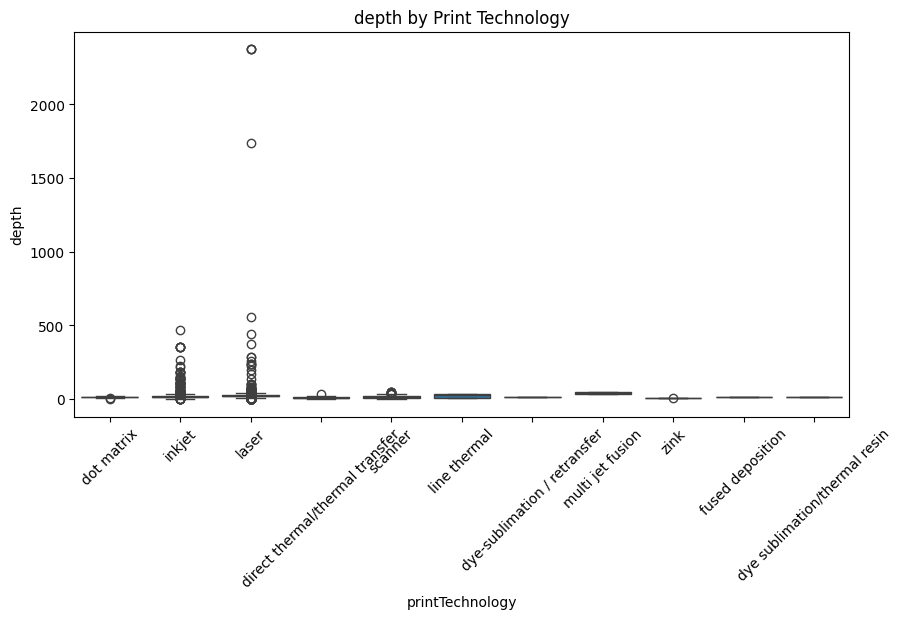

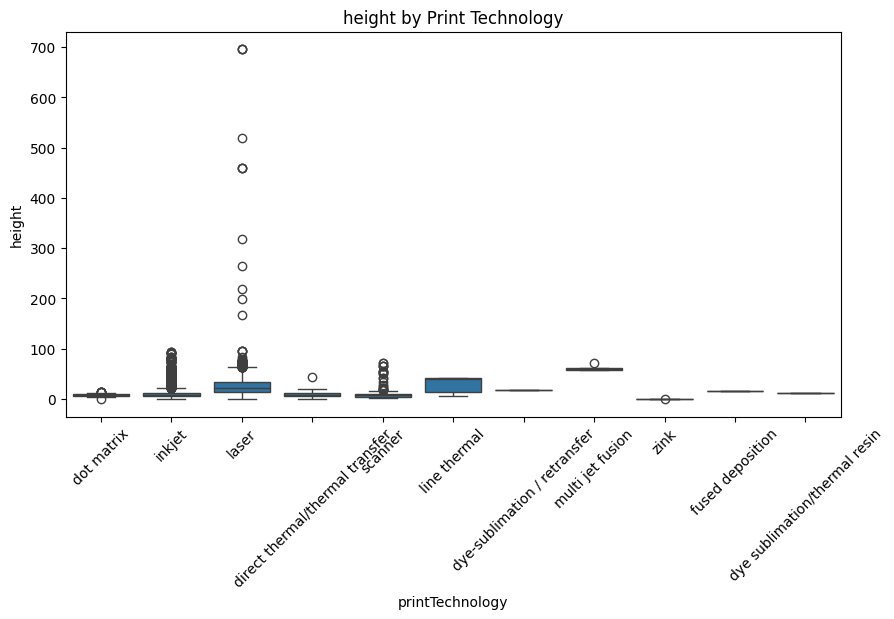

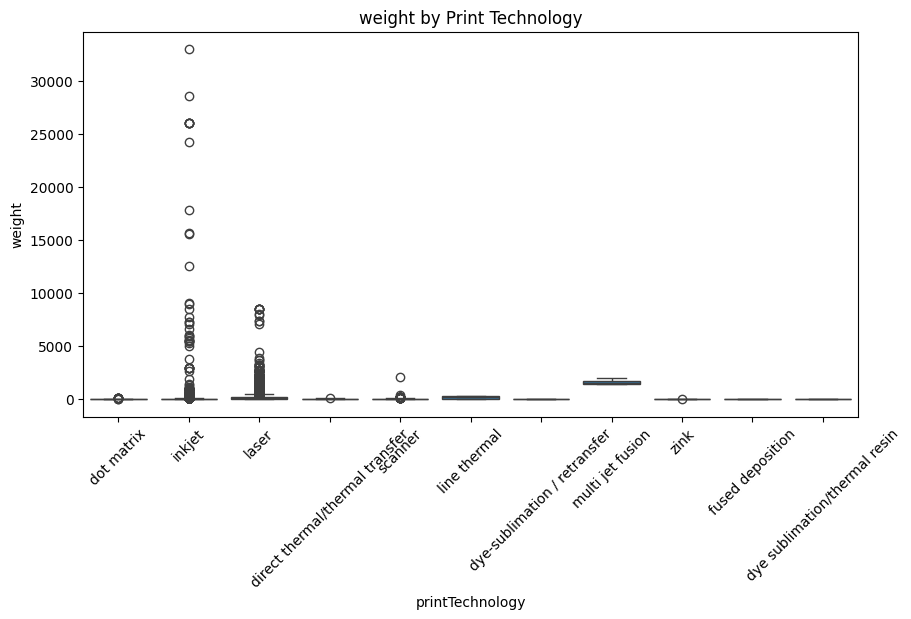

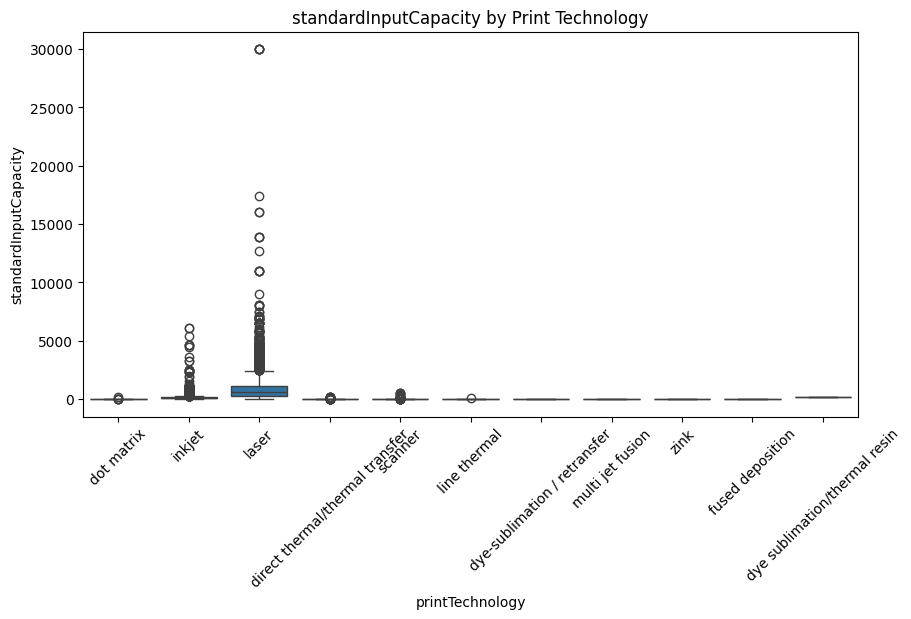

In [46]:
for feature in cols:
    plt.figure(figsize=(10,5))
    
    sns.boxplot(x='printTechnology', y=feature, data=df)
    
    plt.xticks(rotation=45)
    plt.title(feature + " by Print Technology")
    
    plt.show()

In [47]:
# Find correlation between those variable.
corr = df[cols].corr()

corr

,SpeedColor,SpeedMono,listPrice,width,depth,height,weight,standardInputCapacity
SpeedColor,1.000000,0.714337,0.044887,0.021691,0.019457,0.018381,0.034610,0.005838
SpeedMono,0.714337,1.000000,0.051112,0.020908,0.018404,0.015104,0.052450,0.011061
listPrice,0.044887,0.051112,1.000000,0.461862,0.322109,0.390229,0.580595,0.468782
width,0.021691,0.020908,0.461862,1.000000,0.719881,0.770176,0.547140,0.391173
depth,0.019457,0.018404,0.322109,0.719881,1.000000,0.706731,0.395688,0.305225
height,0.018381,0.015104,0.390229,0.770176,0.706731,1.000000,0.370753,0.557339
weight,0.034610,0.052450,0.580595,0.547140,0.395688,0.370753,1.000000,0.270789
standardInputCapacity,0.005838,0.011061,0.468782,0.391173,0.305225,0.557339,0.270789,1.000000


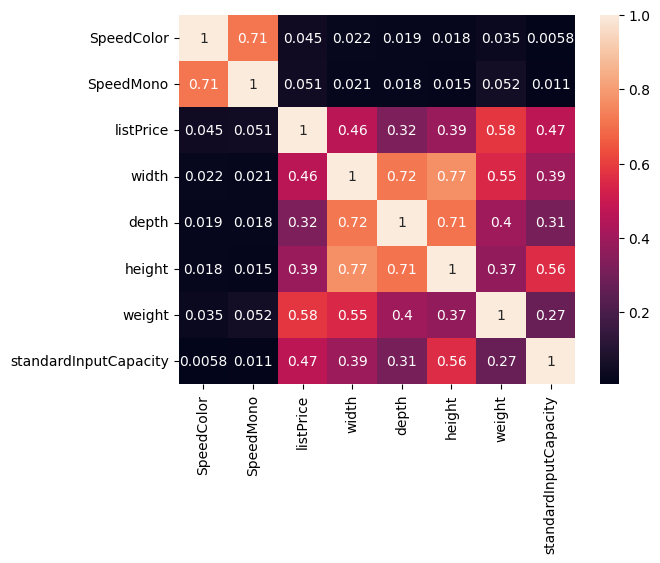

In [48]:
sns.heatmap(corr,annot=True)
plt.show()

In [51]:
 #Z-test vs T-Test. What is p value

stats.ttest_ind(df['SpeedMono'], df['SpeedColor'])

TtestResult(statistic=np.float64(6.802904909183704), pvalue=np.float64(1.0496584856795084e-11), df=np.float64(23754.0))

In [50]:
#z test 
mean1 = df['SpeedMono'].mean()
mean2 = df['SpeedColor'].mean()

std1 = df['SpeedMono'].std()
std2 = df['SpeedColor'].std()

n1 = len(df['SpeedMono'])
n2 = len(df['SpeedColor'])

z = (mean1 - mean2) / ((std1**2/n1 + std2**2/n2)**0.5)

p_value = 2*(1 - stats.norm.cdf(abs(z)))

print(z,p_value)

6.802904909183704 1.0253131677018246e-11


In [52]:
# Does any relation exist between 'SpeedColor' and 'SpeedMono'.
df[['SpeedColor','SpeedMono']].describe()

,SpeedColor,SpeedMono
count,11878.000000,11878.000000
mean,19.352323,51.799728
std,303.340260,422.140735
min,0.000000,0.000000
25%,0.000000,17.000000
50%,2.700000,28.000000
75%,22.000000,45.000000
max,24000.000000,24000.000000


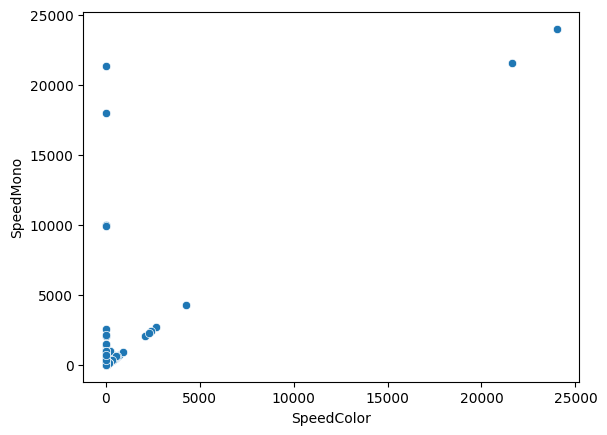

In [53]:
sns.scatterplot(x='SpeedColor',y='SpeedMono',data=df)
plt.show()

In [55]:
#a. Find guid which have z score greater than 3 when we group on  DeviceType, printTechnology and assetClass for feature listPrice
df['listPrice_zscore'] = df.groupby(
    ['deviceType', 'printTechnology', 'assetClass']
)['listPrice'].transform(lambda x: (x - x.mean()) / x.std())

outliers = df[df['listPrice_zscore'].abs() > 3]

outliers[['guid', 'listPrice', 'listPrice_zscore']]

,guid,listPrice,listPrice_zscore
677,BR0806,589.95,3.456057
706,CA0001,9075.00,4.237046
707,CA0002,10999.00,5.320119
785,CN0477,52500.00,3.473796
817,CN1055,63435.66,8.867697
...,...,...,...
11689,XE0178,67269.36,4.630451
11690,XE0179,82652.40,3.023112
11803,XE0955,3363.52,3.588880
11837,ZE0052,10037.00,4.778583


In [56]:
# Compare their Variances of feature listPrice (between Case 1 and 2) (F-ratio Test PRACTICE for Two Equal Variances).
case1 = df[
    (df['deviceType'] == 'multifunctionmono') &
    (df['printTechnology'] == 'laser') &
    (df['assetClass'] == 'Workgroup')
]['listPrice']

In [57]:
case2 = df[
    (df['deviceType'] == 'multifunctioncolor') &
    (df['printTechnology'] == 'laser') &
    (df['assetClass'] == 'Workgroup')
]['listPrice']

In [58]:
var1 = case1.var()
var2 = case2.var()

print(var1, var2)

163048095.9268882 137479596.96172634


In [59]:
f_ratio = var1 / var2
print("F ratio:", f_ratio)

F ratio: 1.1859803165722111


In [60]:
#Categorize a device into 5 classes based on percentile (listPrice). 0-20 as A, 21-40 as B , 41-60 as C, 61-80 as D, 81-100 as E. Plot density plot for converted_speedMono, width, depth, height
df['priceClass'] = pd.qcut(df['listPrice'], 5, labels=['A','B','C','D','E'])

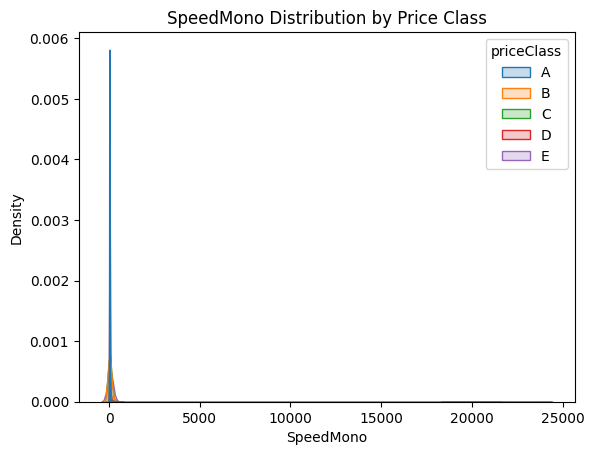

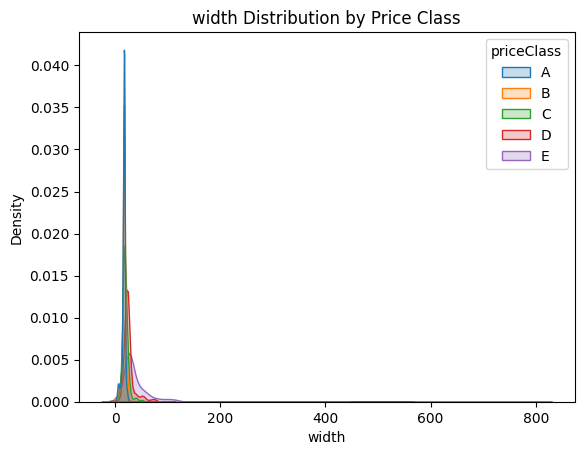

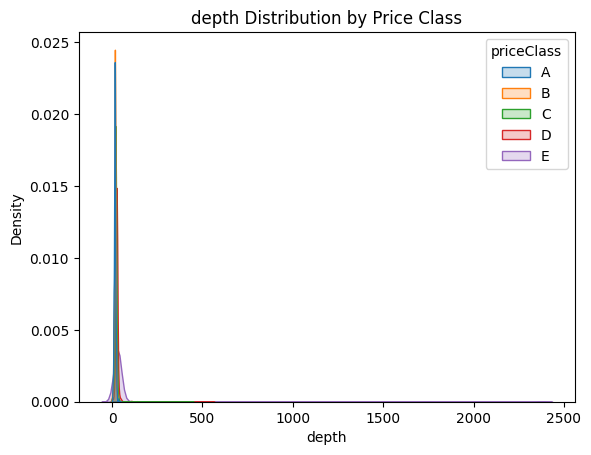

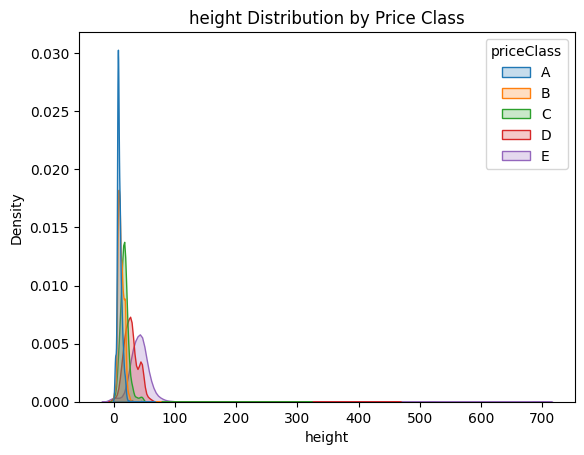

In [61]:
features_to_plot = ['SpeedMono', 'width', 'depth', 'height']

for feature in features_to_plot:
    
    sns.kdeplot(data=df, x=feature, hue='priceClass', fill=True)
    
    plt.title(feature + " Distribution by Price Class")
    plt.show()

In [63]:
#Perform Chi-square Test between 'scan', and 'hasWifi'.
df['scan'] = df['scan'].replace('Optional', False)
df['hasWifi'] = df['hasWifi'].replace('Optional', False)

In [64]:
contingency_table = pd.crosstab(df['scan'], df['hasWifi'])
contingency_table

hasWifi,False,False,TRUE,True
scan,,,,
False,89,161,0,61
False,498,3867,0,620
True,1071,3478,3,2030


In [65]:

from scipy.stats import chi2_contingency

chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square:", chi2_stat)
print("p-value:", p_value)

Chi-square: 835.3428524479721
p-value: 3.5507775713407557e-177
